<a href="https://colab.research.google.com/github/AmedeeRoy/BirdGAN/blob/main/code/basicGAN/basicGAN_HMM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAN

In [68]:
# mount google drive
from google.colab import drive
drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [69]:
%cd drive/My\ Drive/

[Errno 2] No such file or directory: 'drive/My Drive/'
/content/drive/My Drive


## load data

In [70]:
# import python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import datetime as dt
from scipy.interpolate import  splrep, splev
import scipy.stats as st

import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader, Dataset
import torchvision as tv

In [71]:
def dist_ortho(lon1, lat1, lon2, lat2):
    R = 6377726
    pi = np.pi
    a = np.sin((lat1 - lat2)/2*pi/180)**2
    b = np.cos(lat1*pi/180)*np.cos(lat2*pi/180)
    c = np.sin((lon1- lon2)/2* pi/180)**2

    dist = R * 2* np.arcsin( np.sqrt(a + b*c))
    return dist

def cap(lon1, lat1, lon2, lat2):
    pi = np.pi

    # to radians
    lat1 = lat1*pi/180
    lat2 = lat2*pi/180
    lon1 = lon1*pi/180
    lon2 = lon2*pi/180

    delta_lon = lon2-lon1

    a = np.cos(lat1) * np.sin(lat2) - np.sin(lat1)*np.cos(lat2)*np.cos(delta_lon)
    b = np.sin(delta_lon) * np.cos(lat2)

    cap = np.arctan2(b , a)
    cap = cap%(2*pi)

    return cap*180/pi

def get_foraging_duration(data):
    var = []
    for tt in data.trip.unique():
      traj = data[data.trip == tt].copy()
      var.append(np.nansum(traj.dist_colony > 500))
      
    return np.array(var)

def get_daily_dist(data):
    var = []
    for tt in data.trip.unique():
      traj = data[data.trip == tt].copy()
      var.append( np.nansum(traj.step_distance) )
      
    return np.array(var)

def get_time_density(data):
    var = 0
    for tt in data.trip.unique():
      traj = data[data.trip == tt].copy()
      var += (traj.dist_colony.values > 500) 
    return np.array(var)

def get_direction_global(data):
    var = []
    for tt in data.trip.unique():
      traj = data[data.trip == tt].copy()
      dx = traj.lon.values[np.argmax(traj.dist_colony)] - colony[0]
      dy = traj.lat.values[np.argmax(traj.dist_colony)] - colony[1]
      var.append(np.arctan2(dy,dx)*360/(2*np.pi))
    return np.array(var)


def format_data(data):
  data['lon_std'] = (data['lon']- colony[0])* 2
  data['lat_std'] = (data['lat']- colony[1])* 2
  data['dist_colony'] = dist_ortho(colony[0], colony[1], data.lon, data.lat)
  # data['day'] = [t[-5:] for t in data.trip]

  data_new = pd.DataFrame()
  for t in data.trip.unique():
    traj = data[data.trip == t].copy()
    n = len(traj)

    step = dist_ortho( traj.lon.values[0:(n-1)], traj.lat.values[0:(n-1)], traj.lon.values[1:n], traj.lat.values[1:n])
    c = cap( traj.lon.values[0:(n-1)], traj.lat.values[0:(n-1)], traj.lon.values[1:n], traj.lat.values[1:n])
    direction = [d%360 - 360 if d%360 > 180 else d%360 for d in np.diff(c)]

    traj['step_heading'] = np.append(np.nan, c)
    traj['step_distance'] = np.append(np.nan, step)
    traj['step_direction'] = np.append([np.nan, np.nan], direction)
    data_new = data_new.append(traj, ignore_index=True)

  return data_new

In [72]:
data_train = pd.read_table('./data/trips_SV_train.csv', sep = ',')
data_train['datetime'] = pd.to_datetime(data_train['datetime'], format='%Y-%m-%d %H:%M:%S')

data_test = pd.read_table('./data/trips_SV_test.csv', sep = ',')
data_test['datetime'] = pd.to_datetime(data_test['datetime'], format='%Y-%m-%d %H:%M:%S')

data = pd.concat([data_train, data_test])

In [73]:
colony = (-77.264, -11.773)

# data = format_data(data)
data['step_direction_std'] = data.step_direction/180
data['step_speed_std'] = data.step_speed/30

### Add HMM analysis results (momentuHMM)

- obtain distribution for each mode

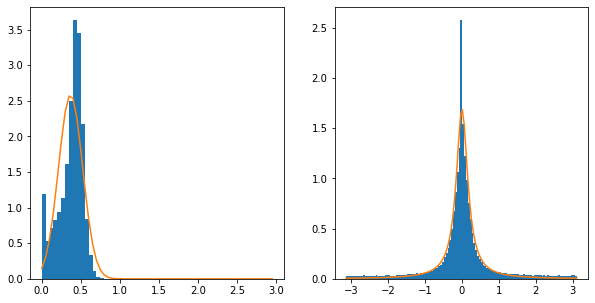

In [74]:
plt.figure(figsize = (10, 5))
plt.subplot(1,2,1)
lognorm_x = np.arange(0, 3, 0.05)
plt.hist(data.step_speed_std, bins = lognorm_x, density = True)
param = st.lognorm.fit(data.step_speed_std)
lognorm_y = st.lognorm.pdf(lognorm_x, *param)
plt.plot(lognorm_x, lognorm_y)

plt.subplot(1,2,2)
cauchy_x = np.arange(-np.pi, np.pi, 0.05)
param = st.cauchy.fit(data.step_direction_std*np.pi)
plt.hist(data.step_direction_std*np.pi, bins = cauchy_x, density = True)
cauchy_y = st.cauchy.pdf(cauchy_x, *param)
plt.plot(cauchy_x, cauchy_y)

plt.show()

In [75]:
input = []

for t in data.trip.unique():
  traj = data[data.trip == t].copy()

  n = len(traj)

  tj = np.zeros((n-3, 4))
  
  tj[:, 0] = traj.step_speed_std[2:(n-1)]
  tj[:, 1] = traj.step_direction_std[2:(n-1)]


  tj[:, 2] = traj.step_speed_std[3:n]
  tj[:, 3] = traj.step_direction_std[3:n]

  input.append(tj)

input = np.vstack(input)

In [76]:
class TrajDataSet(Dataset):
    def __init__(self,  input, transform=None):
        self.data = input
        self.transform = transform

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        
        # select coordinates
        sample = (self.data[idx,:2], self.data[idx,2:])

        if self.transform:
            sample = self.transform(sample)

        return sample

class ToTensor(object):
    """Convert ndarrays in sample to Tensors."""

    def __call__(self, sample):
      x,y = sample
      return (torch.FloatTensor(x), torch.FloatTensor(y))

In [77]:
# hyperparameters
batch_size = 1000


## reduce size dataset
train_set = TrajDataSet(input, transform= ToTensor())
train_loader = DataLoader(train_set, batch_size=batch_size, num_workers = 0, shuffle = True, drop_last=True)

In [78]:
x, y =  next(iter(train_loader))

## GAN - HMM

In [79]:
class HMMGenerator(nn.Module):
    def __init__(self):
        super().__init__()

        self.invG = nn.Sequential( 
            nn.Linear(3, 10),
            nn.Linear(10, 10),
            nn.Linear(10, 2),
            nn.ReLU()
         )

        # self.invH = nn.Sequential( 
        #     nn.Linear(3, 10, bias = False),
        #     nn.Linear(10, 10, bias = False),
        #     nn.Linear(10, 1, bias = False)
        #  )
                 
        self.transition = torch.nn.Parameter(torch.randn(3,3))

        self.L = nn.Sequential( 
            nn.Linear(2, 10, bias = False),
            nn.Linear(10, 10, bias = False),
            nn.Linear(10, 3, bias = False)
         )
        
        self.softmax = nn.Softmax(dim = 1)

    def forward(self, x, z):  
      
      out = self.L(x)
      out = self.softmax(out)
      out = torch.matmul(out, self.transition)
      out = self.softmax(out)
      out = torch.argmax(out, dim = 1).unsqueeze(1)

      out = torch.cat([out, z], 1)
      out = self.invG(out)

      return out

In [80]:
z = torch.rand((batch_size, 2))
gen = HMMGenerator()
gen(x, z).shape

torch.Size([1000, 2])

In [85]:
class HMMDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()

                
        self.linear = nn.Sequential(
            nn.Linear(4, 10),
            nn.Linear(10, 10),
            nn.Linear(10, 10),
            nn.Linear(10, 1),
            nn.Sigmoid()
        )

    def forward(self, x, y):
        out = torch.cat([x,y], dim = 1)
        return self.linear(out)


In [87]:
dis = HMMDiscriminator()
dis(x, y).shape

torch.Size([1000, 1])

# training

In [91]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = HMMGenerator().to(device)
discriminator = HMMDiscriminator().to(device)

criterion = nn.BCELoss()

lr = 0.0002
optim_d = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
optim_g = optim.Adam(generator.parameters(),lr= lr, betas=(0.5, 0.999))

target_ones = torch.ones((batch_size, 1), device=device)
target_zeros = torch.zeros((batch_size, 1), device=device)

Epoch [1/100] -----------------------------------------------------------------------------
G: 0.62, Dr : 0.62, Df : 0.78
Generator score : 100.0 %, Discriminator true positive : 100.0 %, Discriminator true negative : 0.0 %


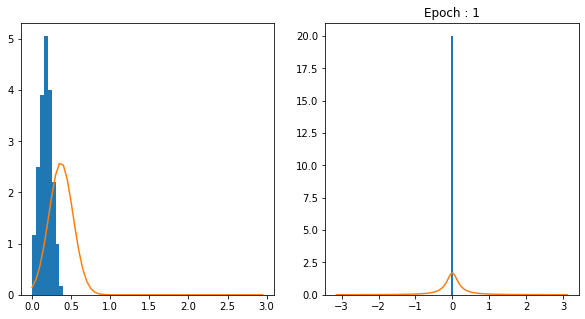

Epoch [6/100] -----------------------------------------------------------------------------
G: 0.7, Dr : 0.7, Df : 0.7
Generator score : 54.5 %, Discriminator true positive : 68.2 %, Discriminator true negative : 41.2 %


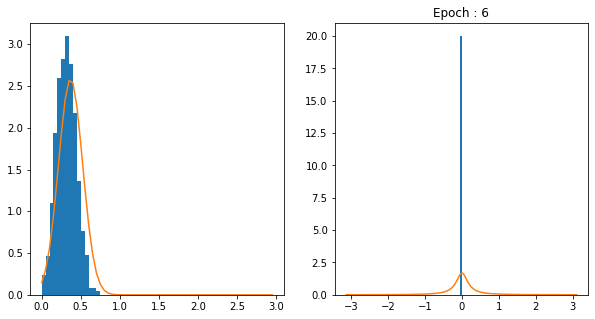

Epoch [11/100] -----------------------------------------------------------------------------
G: 0.7, Dr : 0.7, Df : 0.7
Generator score : 83.7 %, Discriminator true positive : 69.8 %, Discriminator true negative : 10.5 %


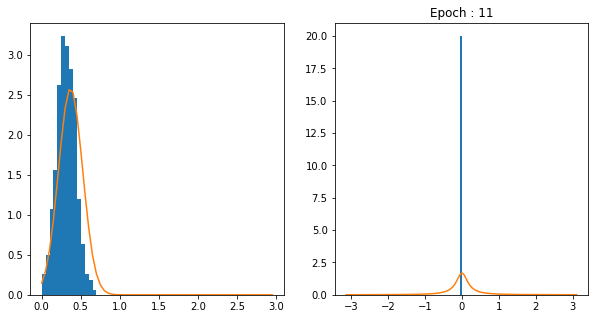

Epoch [16/100] -----------------------------------------------------------------------------
G: 0.7, Dr : 0.7, Df : 0.7
Generator score : 20.6 %, Discriminator true positive : 28.2 %, Discriminator true negative : 81.9 %


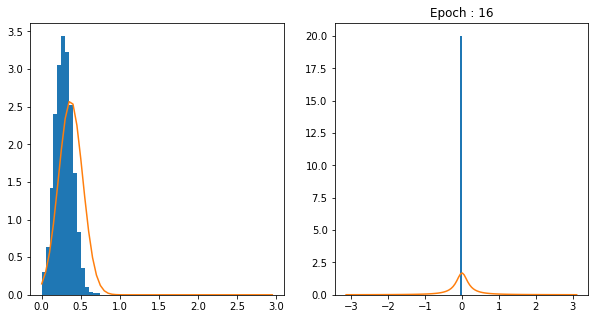

Epoch [21/100] -----------------------------------------------------------------------------
G: 0.7, Dr : 0.7, Df : 0.7
Generator score : 91.0 %, Discriminator true positive : 79.1 %, Discriminator true negative : 8.7 %


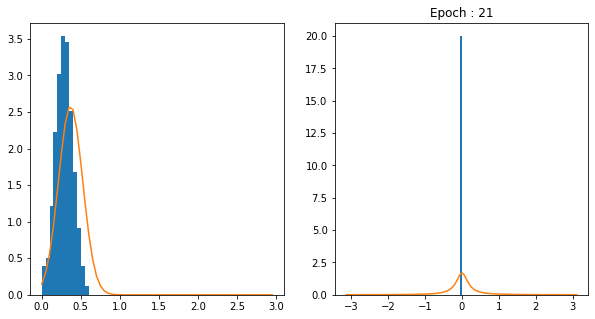

Epoch [26/100] -----------------------------------------------------------------------------
G: 0.7, Dr : 0.7, Df : 0.7
Generator score : 26.9 %, Discriminator true positive : 52.7 %, Discriminator true negative : 69.2 %


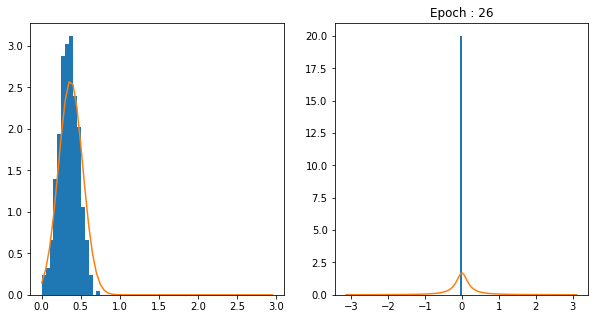

Epoch [31/100] -----------------------------------------------------------------------------
G: 0.7, Dr : 0.7, Df : 0.7
Generator score : 100.0 %, Discriminator true positive : 85.3 %, Discriminator true negative : 0.0 %


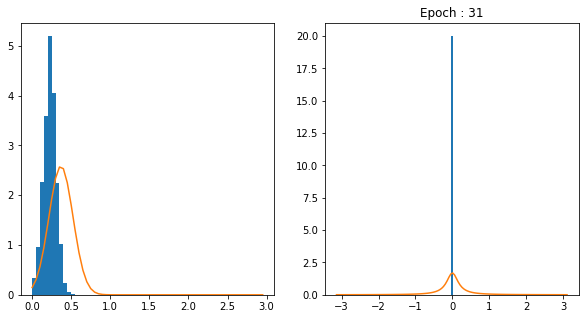

Epoch [36/100] -----------------------------------------------------------------------------
G: 0.7, Dr : 0.7, Df : 0.7
Generator score : 2.6 %, Discriminator true positive : 34.4 %, Discriminator true negative : 93.3 %


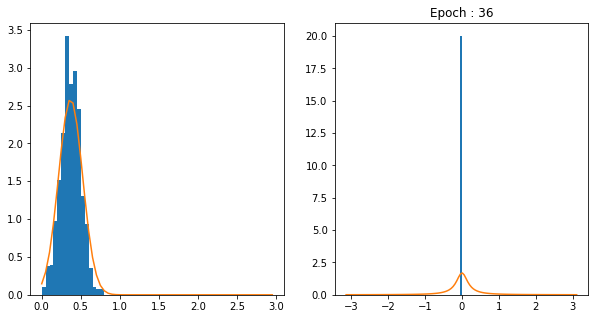

Epoch [41/100] -----------------------------------------------------------------------------
G: 0.7, Dr : 0.7, Df : 0.7
Generator score : 0.2 %, Discriminator true positive : 17.5 %, Discriminator true negative : 99.6 %


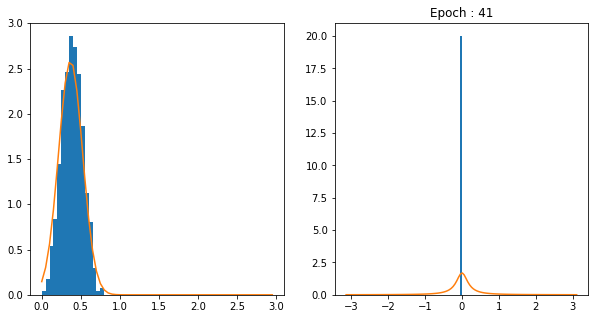

Epoch [46/100] -----------------------------------------------------------------------------
G: 0.7, Dr : 0.7, Df : 0.7
Generator score : 51.5 %, Discriminator true positive : 52.8 %, Discriminator true negative : 47.4 %


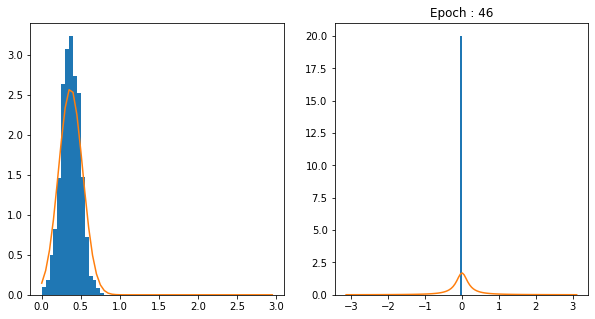

Epoch [51/100] -----------------------------------------------------------------------------
G: 0.7, Dr : 0.7, Df : 0.7
Generator score : 72.6 %, Discriminator true positive : 73.9 %, Discriminator true negative : 23.5 %


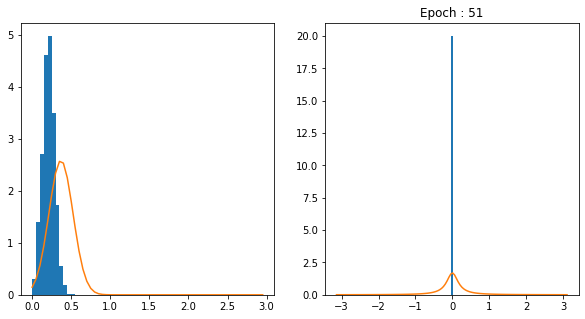

Epoch [56/100] -----------------------------------------------------------------------------
G: 0.7, Dr : 0.7, Df : 0.7
Generator score : 16.0 %, Discriminator true positive : 33.1 %, Discriminator true negative : 83.4 %


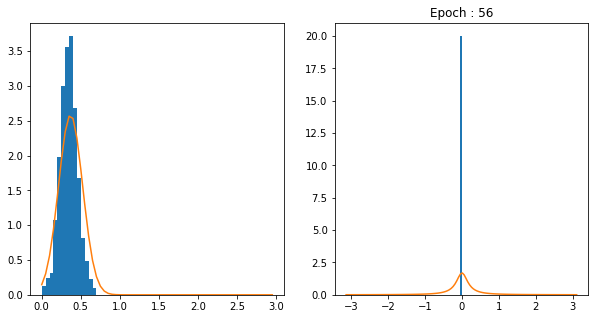

KeyboardInterrupt: ignored

In [92]:
# Train the model
nb_epoch = 100
score = []

for epoch in range(nb_epoch):
    i = 0

    # if epoch%2 == 0:
    #     lr /= 5
    #     optim_d = optim.Adam(discriminator.parameters(), lr=lr)
    #     optim_g = optim.Adam(generator.parameters(),lr=lr)

    loss_g_running, loss_d_real_running, loss_d_fake_running = 0, 0, 0
    for batch, (x, y) in enumerate(train_loader):
        
        i+= 1
        #### TRAIN DISCRIMINATOR
        ## true samples
        x = x.to(device)
        y = y.to(device)

        discriminator.zero_grad()
        pred_real = discriminator(x, y)
        loss_real = criterion(pred_real, target_ones)

        ## false samples
        z = torch.rand((batch_size, 2), device=device)
        with torch.no_grad():
            fake_samples = generator(x, z)
        pred_fake = discriminator(x, fake_samples)
        loss_fake = criterion(pred_fake, target_zeros)
        
        # combine
        loss = (loss_real + loss_fake) / 2
        loss.backward()
        optim_d.step()

        loss_d_real_running += loss_real.item()
        loss_d_fake_running += loss_fake.item()

        # score discriminator
        score_d_fake = np.mean(pred_fake.detach().numpy()<0.5)
        score_d_real = np.mean(pred_real.detach().numpy()>0.5)

        #### TRAIN GENERATOR
        generator.zero_grad()
        z = torch.rand((batch_size, 2), device=device)

        generated = generator(x, z)
        classifications = discriminator(x, generated)
        loss = criterion(classifications, target_ones)
        loss.backward()
        optim_g.step()

        loss_g_running += loss.item()

        # score generator
        score_g = np.mean(classifications.detach().numpy()>0.5)
    

    if epoch%5 == 0:
        print('Epoch [{}/{}] -----------------------------------------------------------------------------'
            .format(epoch+1, nb_epoch, i, len(train_loader)))
        print('G: {}, Dr : {}, Df : {}'
            .format(np.round(loss_g_running/batch, 2), np.round(loss_d_real_running/batch, 2), np.round(loss_d_fake_running/batch, 2)))
        print('Generator score : {} %, Discriminator true positive : {} %, Discriminator true negative : {} %'
            .format(np.round(score_g*100, 2), np.round(score_d_real*100, 2), np.round(score_d_fake*100, 2)))
        

        z = torch.randn((batch_size, 2), device=device)
        with torch.no_grad():
          generated = generator(x, z)
        
        x = generated.detach().numpy()

        plt.figure(figsize = (10, 5))
        plt.subplot(1,2,1)
        plt.hist(x[:,0], bins = lognorm_x, density = True)
        plt.plot(lognorm_x, lognorm_y)

        plt.subplot(1,2,2)
        plt.hist(x[:,1]*np.pi, bins = cauchy_x, density = True)
        plt.plot(cauchy_x, cauchy_y)

        plt.title('Epoch : ' + str(epoch +1))
        plt.show()
        plt.close()

In [ ]:
torch.save(generator, 'HMMGenerator.pt')
torch.save(discriminator, 'HMMDiscriminator.pt')

# generator = torch.load('generator.pt')
# discriminator = torch.load('discriminator.pt')